In [33]:
import pystac_client
import pandas as pd
import planetary_computer 
import matplotlib.pyplot as plt
from shapely.geometry import shape
import numpy as np
import geopandas as gpd
from shapely.geometry import box


#### Methodological Precedent for Ground Truth Data 

The combination of features were influenced by the article Urban Structure Changes in Three Areas of Detroit, Michigan (2014–2018) Utilizing Geographic Object-Based Classification. In this article, they dicussed having to physically go around Detroit with a group of volunteers to actually gather ground truth data about the state of certain parcels. They also calculated NDVI and the percentage of impervious surfaces as a secondary check.

https://www.mdpi.com/2073-445X/12/4/763
- Calculates NDVI and % of impervious surfaces per parcel to as a secondary check 
- Maybe zonal statistics for certain ground truth data (like NDVI) to the clay chips? 
- Reverse aggregation for what majority vote of Clay and Alpha outputs say the parcels are 

In [13]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
bbox = [-83.28785, 42.25518, -82.91056, 42.45022]

#### Data & Preprocessing for Ground Truth Data: Imagery

NAIP imagery of Detroit was collected through Pystac Client for it's familarity and ease of downloading. The reasoning for chosing NAIP data came from attempting to create a 153.6 x 153.6 meter grid of all the NAIP tiles to prepare it to be put into the Clay model. The issue of computational rigor as the Detroit area was too large to compute for such small Clay chips. 

Describe your dataset(s), including source, spatial and temporal extent, resolution, and bands or features used. Discuss any data quality issues you encountered and how you addressed them. Explain your preprocessing steps and feature engineering choices, with justification for each decision.

In [18]:
minx, miny, maxx, maxy = bbox
aoi = gpd.GeoDataFrame(
    geometry=[box(minx, miny, maxx, maxy)],
    crs="EPSG:4326" # degrees of latitude and longitude
)

aoi_utm = aoi.to_crs("EPSG:26917") # for assessing Detroit in meters

In [19]:
cell = 153.6  # meters

minx, miny, maxx, maxy = aoi_utm.total_bounds

xs = np.arange(minx, maxx, cell)
ys = np.arange(miny, maxy, cell)

polys = []
for x in xs:
    for y in ys:
        polys.append(box(x, y, x + cell, y + cell))

grid_153 = gpd.GeoDataFrame({"geometry": polys}, crs=aoi_utm.crs)

In [20]:
grid_153_4326 = grid_153.to_crs("EPSG:4326") # back to degrees of latitude and longitude, clay and alpha only accept these 

<Axes: >

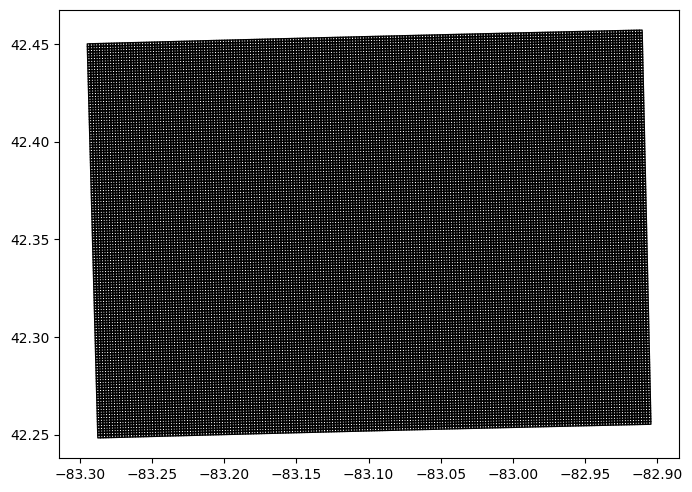

In [21]:
grid_153_4326.plot(figsize=(8, 8), edgecolor="black", facecolor="none") # plot the grid

In [22]:
# Summer 2018 NAIP imagery

search_2018 = catalog.search(
    collections=["naip"],
    bbox=bbox,
    datetime="2018-06-01/2018-09-30"
)

# Check its not zero

items_2018 = list(search_2018.item_collection())
print(f"2018 items: {len(items_2018)}")

2018 items: 25


In [23]:
# Summer 2022 NAIP imagery

search_2022 = catalog.search(
    collections=["naip"],
    bbox=bbox,
    datetime="2022-06-01/2022-09-30"
)

# Check its not zero

items_2022 = list(search_2022.item_collection())
print(f"2022 items: {len(items_2022)}")

2022 items: 25


In [24]:
# Get the URL and geometry for each tile

rows_2018 = []
for item in items_2018:
    rows_2018.append({
        "geometry": shape(item.geometry),   
        "url": item.assets["image"].href
    })

naip_grid_2018 = gpd.GeoDataFrame(rows_2018, geometry="geometry", crs="EPSG:4326")

rows_2022 = []
for item in items_2022:
    rows_2022.append({
        "geometry": shape(item.geometry),   
        "url": item.assets["image"].href
    })     
naip_grid_2022 = gpd.GeoDataFrame(rows_2022, geometry="geometry", crs="EPSG:4326")

<Axes: >

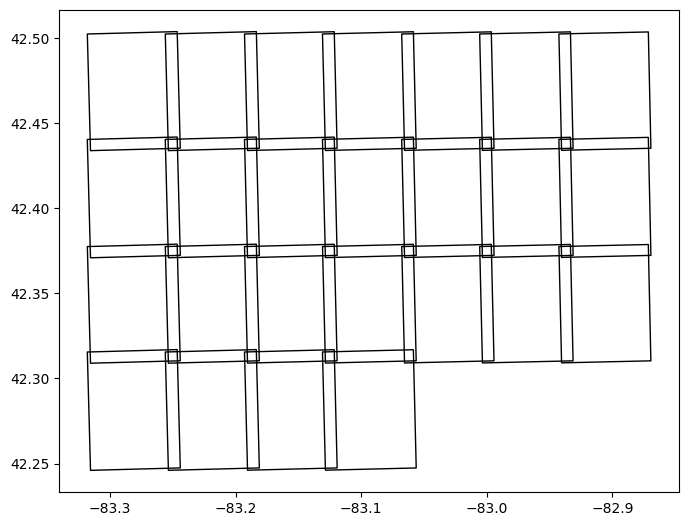

In [25]:
naip_grid_2018.plot(figsize=(8, 8), edgecolor="black", facecolor="none")

<Axes: >

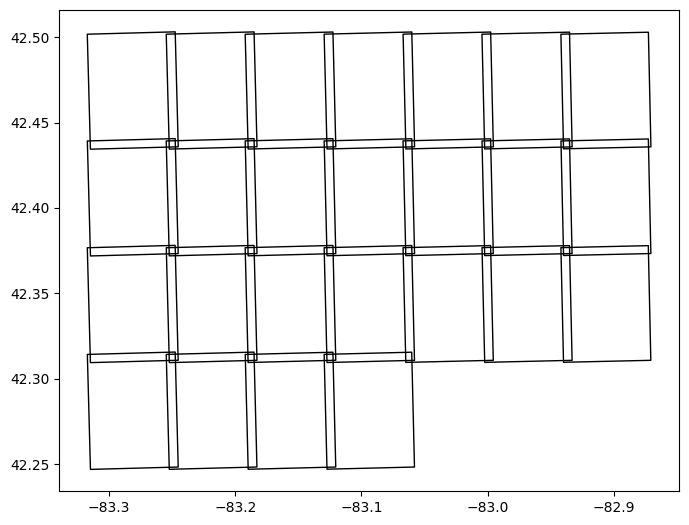

In [26]:
naip_grid_2022.plot(figsize=(8, 8), edgecolor="black", facecolor="none")

In [27]:
# Join the grid with NAIP tiles so they are spatially joined and the urls are also attached to the grid cells 

joined_grid_2018_26917 = gpd.sjoin(grid_153, naip_grid_2018.to_crs("EPSG:26917"), how="left", predicate="intersects")

joined_grid_2022_26917 = gpd.sjoin(grid_153, naip_grid_2022.to_crs("EPSG:26917"), how="left", predicate="intersects")


In [28]:
# Check the results through the dataframe columns, should see url

print(joined_grid_2018_26917.head())

print(joined_grid_2022_26917.head())

                                            geometry  index_right  \
0  POLYGON ((311433.308 4679876.421, 311433.308 4...          2.0   
1  POLYGON ((311433.308 4680030.021, 311433.308 4...          2.0   
2  POLYGON ((311433.308 4680183.621, 311433.308 4...          2.0   
3  POLYGON ((311433.308 4680337.221, 311433.308 4...          2.0   
4  POLYGON ((311433.308 4680490.821, 311433.308 4...          2.0   

                                                 url  
0  https://naipeuwest.blob.core.windows.net/naip/...  
1  https://naipeuwest.blob.core.windows.net/naip/...  
2  https://naipeuwest.blob.core.windows.net/naip/...  
3  https://naipeuwest.blob.core.windows.net/naip/...  
4  https://naipeuwest.blob.core.windows.net/naip/...  
                                            geometry  index_right  \
0  POLYGON ((311433.308 4679876.421, 311433.308 4...         21.0   
1  POLYGON ((311433.308 4680030.021, 311433.308 4...         21.0   
2  POLYGON ((311433.308 4680183.621, 311433.308 

Detroit Open Data Portal:
- DLBA Vacant Land Program Sales; between 2014 and 2025; separates between Neighborhood and Side Lots
- Completed Commercial Demolitions since 2014
- Completed Residential Demolitions since 2014 to 2026
- Parcels (current) last updated in 2024 but year built goes up to 2017 
- (Not Available for 2018-2023) Tenative Assessment Roll; Property Description and Use Code Description describe vacancy status and whether it's residential or commercial 

Urban Structure Changes in Three Areas of Detroit, Michigan (2014–2018) Utilizing Geographic Object-Based Classification
https://www.mdpi.com/2073-445X/12/4/763
- Calculates NDVI and % of impervious surfaces per parcel to as a secondary check 
- Maybe zonal statistics for certain ground truth data (like NDVI) to the clay chips? 
- Reverse aggregation for what majority vote of Clay and Alpha outputs say the parcels are 

Before 2022:
  - Demolitions (residential + commercial) = created vacant land
  - DLBA sales means some vacant lots were sold (may have been developed)
  - If demolished and not in current parcels, still vacant in 2022
  - If sold but not in current parcels, still may be vacant or underdeveloped

  None of the df's except current parcel data are before 2014 so our understanding of vacant or demolished land would be betwwen 2014-2018.  

### Residential Demolition Data

In [30]:
# Loading residential demolition data set 

res_demo = gpd.read_file("Completed_Residential_Demolitions/Completed_Residential_Demolitions.shp")

print(res_demo.head(10)) # find which column indicates a demolition date


             address   parcel_id                            contractor  \
0   16868 Mark Twain   22036858.           Inner City Contracting, LLC   
1    18981 Riverview   22121944.                             Blue Star   
2    18968 Riverview   22121914.                               Smalley   
3    18975 Riverview   22121945.                        Homrich (HHF2)   
4        8534 Lyford   17002489.           Inner City Contracting, LLC   
5     11745 Appoline   22021860.                        Homrich (HHF2)   
6      9931 St Marys   22059331.                               Smalley   
7     5901 Beechwood   16011581.  Salenbien Trucking & Excavating Inc.   
8     11730 Appoline  22020884-5                     Adamo Group, Inc.   
9  19209 Asbury Park   22061762.  Salenbien Trucking & Excavating Inc.   

      price funding_so demolition                    demo_rfp_g commercial  \
0  30550.00    Non-HHF 2024-11-27                Bond Group Q19         No   
1  13609.00        HHF 2018-1

In [31]:
# Checking that demolition date is in datetime format to cross check with current parcels

print(f'Residential demolitions date dtype: {res_demo["demolition"].dtype}') 

Residential demolitions date dtype: datetime64[ms]


In [34]:
# Filtering residential demos by naip date and checking the range and length after filtering

res_demo_2018 = res_demo[res_demo["demolition"] <= pd.to_datetime("2018-09-30")]
res_demo_2022 = res_demo[res_demo["demolition"] <= pd.to_datetime("2022-09-30")]


print(f'Residential demolitions between {res_demo["demolition"].min().date()} and {res_demo["demolition"].max().date()}: {len(res_demo)}')

print(f'Residential demolitions between {res_demo_2018["demolition"].min().date()} and {res_demo_2018["demolition"].max().date()}: {len(res_demo_2018)}')

print(f'Residential demolitions between {res_demo_2022["demolition"].min().date()} and {res_demo_2022["demolition"].max().date()}: {len(res_demo_2022)}')


Residential demolitions between 2014-01-02 and 2026-04-14: 31550
Residential demolitions between 2014-01-02 and 2018-09-29: 15198
Residential demolitions between 2014-01-02 and 2022-09-30: 24319


### Vacant Land Sales Data

In [35]:
# Loading vacant land sales dataset
vac_land = gpd.read_file("dlba_vacant_land_program_sales/DLBA_Vacant_Land_Sales.shp")

print(vac_land.head(10)) # find which column indicates a sale date


  dlba_sale_            address  sale_close  amt_final_        sale_progr  \
0   A-034564  8865 Abington Ave  2015-08-10       100.0          Side Lot   
1   A-136281     4069 Roosevelt  2017-05-19       100.0          Side Lot   
2   A-344001       9929 Chenlot  2022-09-19       100.0          Side Lot   
3   A-014784      15869 Indiana  2015-04-28       100.0          Side Lot   
4   A-180287      3985 St Clair  2018-07-17       100.0          Side Lot   
5   A-354658       3209 Hammond  2024-01-23       250.0  Neighborhood Lot   
6   A-049564         8960 ASTOR  2016-02-25       100.0          Side Lot   
7   A-223921        8318 Braile  2018-12-11       100.0          Side Lot   
8   A-127789      14830 Indiana  2021-01-29       100.0          Side Lot   
9   A-026313       19645 Hoover  2017-03-25       100.0          Side Lot   

                 block_rang council_di            neighborho zip_code  \
0    6700-7199 Abington Ave          7         Joy Community    48228   
1    3

In [36]:
# Checking that sale_close date is in datetime format 

print(f'Vacant land sale close date dtype: {vac_land["sale_close"].dtype}') 

Vacant land sale close date dtype: object


In [37]:
# Converting sale_close to datetime format

vac_land["sale_close"] = pd.to_datetime(vac_land["sale_close"])

print(f'Vacant land sale close date new dtype: {vac_land["sale_close"].dtype}')


Vacant land sale close date new dtype: datetime64[ns]


In [38]:
# Checking range and length after filtering to naip date

vac_land_2018 = vac_land[vac_land["sale_close"] <= pd.to_datetime("2018-09-30")]
vac_land_2022 = vac_land[vac_land["sale_close"] <= pd.to_datetime("2022-09-30")]

print(f'Vacant land sales between {vac_land["sale_close"].min().date()} and {vac_land["sale_close"].max().date()}: {len(vac_land)}')

print(f'Vacant land sales between {vac_land_2018["sale_close"].min().date()} and {vac_land_2018["sale_close"].max().date()}: {len(vac_land_2018)}')

print(f'Vacant land sales between {vac_land_2022["sale_close"].min().date()} and {vac_land_2022["sale_close"].max().date()}: {len(vac_land_2022)}')

Vacant land sales between 2014-08-13 and 2025-12-19: 31705
Vacant land sales between 2014-08-13 and 2018-09-28: 10130
Vacant land sales between 2014-08-13 and 2022-09-30: 22709


### Commercial Demolition Data

In [39]:
# Loading commercial demolition dataset

com_demo = gpd.read_file("Commercial_Demolitions/Commercial_Demolitions.shp")

print(com_demo.head(10))


              address   parcel_id           status abatement_ demo_cost  \
0      2740 Fullerton   10003808.       Demolished       None      None   
1       12555 Gratiot  21028952-3  Demo Contracted       None      None   
2         2426 Tuxedo   10003291.       Demolished       None      None   
3         2750 Poplar   10000409.  Demo Contracted       None      None   
4  5385 E Outer Drive  17016300-1       Demolished       None      None   
5         8725 Harper  19001817-8    Demo Pipeline       None      None   
6         6201 Auburn   22093044.       Demolished       None      None   
7       13545 Gratiot   21029020.    Demo Pipeline       None      None   
8    4330 E Mcnichols  13007184-5       Demolished       None      None   
9     15000 Mackenzie   22044630.    Demo Pipeline       None      None   

  demo_proce projected_         env_group_           demo_rfp_g  demo_date  \
0        NaT        NaT               None  Emergency 9.24.2024 2025-01-28   
1 2023-12-11      

In [40]:
# Multiple demolition statuses and multiple potential demoliton columns

print(f'Demolition statuses: {com_demo["status"].unique()}') # checking the different statuses 

print(f'Demolition date dtype: {com_demo["demo_date"].dtype}') # checking to see if the actual demo date is in datetime format


Demolition statuses: ['Demolished' 'Demo Contracted' 'Demo Pipeline']
Demolition date dtype: datetime64[ms]


In [41]:
# Filtering commerical demos by demo_date, already in datetime format 

com_demo_2018 = com_demo[com_demo["demo_date"] <= pd.to_datetime("2018-09-30")] # getting only demolitions processed before naip date

com_demo_2022 = com_demo[com_demo["demo_date"] <= pd.to_datetime("2022-09-30")] 

print(com_demo_2022.head(10))

print(f'Demolition statuses after filtering: {com_demo_2022["status"].unique()}') # checking just to confirm


           address      parcel_id      status abatement_ demo_cost demo_proce  \
13      5901 Moran      13010272.  Demolished       None      None        NaT   
16   4049 W Vernor      14000327.  Demolished       None      None        NaT   
19   9548 Van Dyke     17009603-4  Demolished       None      None 2016-06-23   
21       503 Hague      03002280.  Demolished       None      None 2016-06-23   
24   8349 Van Dyke      15005640.  Demolished       None      None 2016-06-23   
25   8635 E Forest      17000611.  Demolished       None      None 2016-06-24   
26    6426 30th St      14011865.  Demolished       None      None        NaT   
27   8737 E Forest      19001239.  Demolished       None      None 2016-06-24   
28  4870 E Davison      13007482.  Demolished       None      None 2016-07-25   
29   12345 Gratiot  21028943.002L  Demolished       None      None 2016-06-23   

   projected_ env_group_         demo_rfp_g  demo_date  ... winter_gra  \
13 2016-10-09       None  Emergenc

In [42]:
# Confirm the range of commerical demolition dates 

print(f'Commercial demolitions completed between {com_demo["demo_date"].min().date()} and {com_demo["demo_date"].max().date()}: {len(com_demo)}')

print(f'Commercial demolitions completed between {com_demo_2018["demo_date"].min().date()} and {com_demo_2018["demo_date"].max().date()}: {len(com_demo_2018)}')

print(f'Commercial demolitions completed between {com_demo_2022["demo_date"].min().date()} and {com_demo_2022["demo_date"].max().date()}: {len(com_demo_2022)}')

Commercial demolitions completed between 2014-01-03 and 2025-01-28: 1229
Commercial demolitions completed between 2014-01-03 and 2018-09-20: 596
Commercial demolitions completed between 2014-01-03 and 2022-09-26: 854


### Current Parcel Data 

In [43]:
# Loading current parcel data to cross check with demolitions and vacant land sales to infer building existence

pd.set_option('display.width', 2000)  # stop columns from wrapping 

current_parcel = gpd.read_file("parcel_file_current.geojson")

print(current_parcel.head(10)) # find which columns might indicate the buildings existence 


   object_id   parcel_id          address zip_code                       taxpayer_1                     taxpayer_2                  taxpayer_address    taxpayer_city taxpayer_state taxpayer_zip_code  ...  landmap subdivision  local_historic_district       neighborhood council_district street_number  street_prefix street_name  ObjectId                                           geometry
0        243   02000184.         712 CASS    48226       DETROIT CLUB HOLDINGS, LLC                                                     712 CASS AVE          DETROIT             MI             48226  ...      001                                 None           Downtown                6         712.0                       CASS         1  POLYGON ((-83.05094 42.32975, -83.05072 42.329...
1        244   02000154.   422 W CONGRESS    48226        CHICKPEA DEVELOPMENT, LLC                                 1900 NORTH BAYSHORE DR UNIT 4704            MIAMI             FL             33132  ...      001            

In [44]:
# Checking that the relevant columns are in the correct format 

print(f'Year Built dtype: {current_parcel["year_built"].dtype}')

print(f'Sale Date dtype: {current_parcel["sale_date"].dtype}')

print(f'Parcel Modified Date dtype: {current_parcel["parcel_modified_date"].dtype}')


Year Built dtype: float64
Sale Date dtype: object
Parcel Modified Date dtype: object


In [45]:
# Cleaning up the dates and years to make it more consistent 

current_parcel["year_built"] = pd.to_numeric(current_parcel["year_built"], errors="coerce").astype("Int64") 

current_parcel["sale_date"] = pd.to_datetime(current_parcel["sale_date"], errors="coerce").dt.normalize()

current_parcel["parcel_modified_date"] = pd.to_datetime(current_parcel["parcel_modified_date"], errors="coerce").dt.normalize()


# Checking that the conversions worked and the dtypes are correct

print(f'Year Built New dtype: {current_parcel["year_built"].dtype}')

print(f'Sale Date New dtype: {current_parcel["sale_date"].dtype}')

print(f'Parcel Modified Date New dtype: {current_parcel["parcel_modified_date"].dtype}')


# rechecking the dataframe after conversions

print(current_parcel.head(10))

Year Built New dtype: Int64
Sale Date New dtype: datetime64[ns]
Parcel Modified Date New dtype: datetime64[ns]
   object_id   parcel_id          address zip_code                       taxpayer_1                     taxpayer_2                  taxpayer_address    taxpayer_city taxpayer_state taxpayer_zip_code  ...  landmap subdivision  local_historic_district       neighborhood council_district street_number  street_prefix street_name  ObjectId                                           geometry
0        243   02000184.         712 CASS    48226       DETROIT CLUB HOLDINGS, LLC                                                     712 CASS AVE          DETROIT             MI             48226  ...      001                                 None           Downtown                6         712.0                       CASS         1  POLYGON ((-83.05094 42.32975, -83.05072 42.329...
1        244   02000154.   422 W CONGRESS    48226        CHICKPEA DEVELOPMENT, LLC                              

In [46]:
# Checking the range of all the new dates 

print(f'Oldest parcel built in {current_parcel["year_built"].min()} and youngest parcel built in {current_parcel["year_built"].max()}.')

print(f'Oldest sale date: {current_parcel["sale_date"].min().date()}\nYoungest sale date: {current_parcel["sale_date"].max().date()}')

print(f'Oldest parcel modified date: {current_parcel["parcel_modified_date"].min().date()}\nYoungest parcel modified date: {current_parcel["parcel_modified_date"].max().date()}')


Oldest parcel built in 1684 and youngest parcel built in 2107.
Oldest sale date: 1911-03-01
Youngest sale date: 2026-04-02
Oldest parcel modified date: 2016-05-25
Youngest parcel modified date: 2025-05-30


In [47]:
# See if 2107 is the only future year built, which would indicate a likely data error

print(len(current_parcel[current_parcel['year_built'] == 2107])) # only one parcel with future year built 

current_parcel.loc[current_parcel['year_built'] == 2107, 'year_built'] = 2017 # correcting the error


#check the range after correction

print(f'Oldest parcel built in {current_parcel["year_built"].min()} and youngest parcel built in {current_parcel["year_built"].max()}.')

1
Oldest parcel built in 1684 and youngest parcel built in 2025.


In [48]:
# Check range after filtering to naip date

# 2018 truncating of parcel data
current_parcel_2018 = current_parcel[current_parcel["year_built"] <= 2018]

current_parcel_2018 = current_parcel_2018[(current_parcel_2018["sale_date"] <= pd.to_datetime("2018-09-30")) | (current_parcel_2018["sale_date"].isna())]

current_parcel_2018 = current_parcel_2018[(current_parcel_2018["parcel_modified_date"] <= pd.to_datetime("2018-09-30")) | (current_parcel_2018["parcel_modified_date"].isna())]

# 2022 truncating of parcel data 
current_parcel_2022 = current_parcel[current_parcel["year_built"] <= 2022]

current_parcel_2022 = current_parcel_2022[(current_parcel_2022["sale_date"] <= pd.to_datetime("2022-09-30")) | (current_parcel_2022["sale_date"].isna())]

current_parcel_2022 = current_parcel_2022[(current_parcel_2022["parcel_modified_date"] <= pd.to_datetime("2022-09-30")) | (current_parcel_2022["parcel_modified_date"].isna())]


#2018 ranges and lengths
print(f'Number of parcels built between {current_parcel_2018["year_built"].min()} and {current_parcel_2018["year_built"].max()}: {len(current_parcel_2018)}')

print(f'Number of parcels with sale date between {current_parcel_2018["sale_date"].min().date()} and {current_parcel_2018["sale_date"].max().date()}: {current_parcel_2018["sale_date"].notna().sum()}')

print(f'Number of parcels with modified date between {current_parcel_2018["parcel_modified_date"].min().date()} and {current_parcel_2018["parcel_modified_date"].max().date()}: {current_parcel_2018["parcel_modified_date"].notna().sum()}')


#2022 ranges and lengths 
print(f'Number of parcels built between {current_parcel_2022["year_built"].min()} and {current_parcel_2022["year_built"].max()}: {len(current_parcel_2022)}')

print(f'Number of parcels with sale date between {current_parcel_2022["sale_date"].min().date()} and {current_parcel_2022["sale_date"].max().date()}: {current_parcel_2022["sale_date"].notna().sum()}')

print(f'Number of parcels with modified date between {current_parcel_2022["parcel_modified_date"].min().date()} and {current_parcel_2022["parcel_modified_date"].max().date()}: {current_parcel_2022["parcel_modified_date"].notna().sum()}')


Number of parcels built between 1684 and 2018: 127779
Number of parcels with sale date between 1911-03-01 and 2018-09-30: 102379
Number of parcels with modified date between 2016-05-25 and 2018-09-10: 928
Number of parcels built between 1684 and 2022: 158669
Number of parcels with sale date between 1911-03-01 and 2022-09-30: 128630
Number of parcels with modified date between 2016-05-25 and 2022-08-26: 18789


In [49]:
# Create simplified dataframe to cross check between demolitions and vacant lots sales

simp_com_demo8 = com_demo_2018[["parcel_id", "demo_date"]]
simp_res_demo8 = res_demo_2018[["parcel_id", "demolition"]]
simp_vac_sale8 = vac_land_2018[["parcel_id", "sale_close"]]

simp_res_demo2 = res_demo_2022[["parcel_id", "demolition"]]
simp_com_demo2 = com_demo_2022[["parcel_id", "demo_date"]]
simp_vac_sale2 = vac_land_2022[["parcel_id", "sale_close"]]

merged = (current_parcel_2022
    .merge(simp_com_demo2, on="parcel_id", how="left", suffixes=("", "_2022"))
    .merge(simp_vac_sale2, on="parcel_id", how="left", suffixes=("", "_2022"))
    .merge(simp_res_demo2, on="parcel_id", how="left", suffixes=("", "_2022"))
    .merge(simp_com_demo8, on="parcel_id", how="left", suffixes=("", "_2018"))
    .merge(simp_vac_sale8, on="parcel_id", how="left", suffixes=("", "_2018"))
    .merge(simp_res_demo8, on="parcel_id", how="left", suffixes=("", "_2018"))  # fix duplicate columns 
)

print(merged.head(10))


   object_id     parcel_id          address zip_code                     taxpayer_1 taxpayer_2                  taxpayer_address  taxpayer_city taxpayer_state taxpayer_zip_code  ...  street_prefix street_name  ObjectId                                           geometry demo_date sale_close  demolition demo_date_2018  sale_close_2018  demolition_2018
0        243     02000184.         712 CASS    48226     DETROIT CLUB HOLDINGS, LLC                                 712 CASS AVE        DETROIT             MI             48226  ...                       CASS         1  POLYGON ((-83.05094 42.32975, -83.05072 42.329...       NaT        NaT         NaT            NaT              NaT              NaT
1        244     02000154.   422 W CONGRESS    48226      CHICKPEA DEVELOPMENT, LLC             1900 NORTH BAYSHORE DR UNIT 4704          MIAMI             FL             33132  ...              W    CONGRESS         2  POLYGON ((-83.05091 42.32852, -83.05073 42.328...       NaT        NaT      

In [50]:
# helper function to build specific flags for 2018 and 2022 that compares overlapping parcel and demo and vacant land data 

def build_flags(merged, year):
    
    # column names depend on year suffix
    demo_date_col  = "demo_date"        if year == 2022 else f"demo_date_{year}"
    demolition_col = "demolition"       if year == 2022 else f"demolition_{year}"
    sale_close_col = "sale_close"       if year == 2022 else f"sale_close_{year}"
    
    # demolished flags
    merged[f"demo_com_{year}"] = (
        merged[demo_date_col].notna() & 
        (merged[demo_date_col].dt.year < year)
    )
    merged[f"demo_res_{year}"] = (
        merged[demolition_col].notna() & 
        (merged[demolition_col].dt.year < year)
    )
    merged[f"new_lot_{year}"] = (
        merged[sale_close_col].notna() & 
        (merged[sale_close_col].dt.year < year)
    )
    
    # rebuilt flags
    merged[f"rebuilt_com_{year}"] = (
        merged[demo_date_col].notna() & (
            (merged["year_built"] > merged[demo_date_col].dt.year) |
            ((merged["parcel_modified_date"].notna()) & (merged["parcel_modified_date"] > merged[demo_date_col])) |
            ((merged["sale_date"].notna()) & (merged["sale_date"] > merged[demo_date_col]))
        ) & (merged[demo_date_col].dt.year < year)
    )
    merged[f"rebuilt_res_{year}"] = (
        merged[demolition_col].notna() & (
            (merged["year_built"] > merged[demolition_col].dt.year) |
            ((merged["parcel_modified_date"].notna()) & (merged["parcel_modified_date"] > merged[demolition_col])) |
            ((merged["sale_date"].notna()) & (merged["sale_date"] > merged[demolition_col]))
        ) & (merged[demolition_col].dt.year < year)
    )
    
    merged[f"rebuilt_lots_{year}"] = (
        merged[sale_close_col].notna() & (
            (merged["year_built"] > merged[sale_close_col].dt.year) |
            ((merged["parcel_modified_date"].notna()) & (merged["parcel_modified_date"] > merged[sale_close_col])) |
            ((merged["sale_date"].notna()) & (merged["sale_date"] > merged[sale_close_col]))
        ) & (merged[sale_close_col].dt.year < year)
    )

    # final vacancy flag
    merged[f"likely_vacant_{year}"] = (
        (merged[f"demo_res_{year}"] | merged[f"demo_com_{year}"] | merged[f"new_lot_{year}"]) &
        ~(merged[f"rebuilt_res_{year}"] | merged[f"rebuilt_com_{year}"])
    )
    
    print(f"\n{year} summary:")
    print(f" Number of Demolished Commercial:{merged[f'demo_com_{year}'].sum()}")
    print(f" Number of Demolished Residential:{merged[f'demo_res_{year}'].sum()}")
    print(f" Number of Inferred New lots:{merged[f'new_lot_{year}'].sum()}")
    print(f" Number of Rebuilt Commercial:{merged[f'rebuilt_com_{year}'].sum()}")
    print(f" Number of Rebuilt Residential:{merged[f'rebuilt_res_{year}'].sum()}")
    print(f" Number of Rebuilt Lots: {merged[f'rebuilt_lots_{year}'].sum()}")
    print(f" Number of Likely Vacant Parcels: {merged[f'likely_vacant_{year}'].sum()}")
    
    return merged

# Run for both years
merged = build_flags(merged, 2018)
merged = build_flags(merged, 2022)



2018 summary:
 Number of Demolished Commercial:6
 Number of Demolished Residential:27
 Number of Inferred New lots:36
 Number of Rebuilt Commercial:2
 Number of Rebuilt Residential:9
 Number of Rebuilt Lots: 7
 Number of Likely Vacant Parcels: 54

2022 summary:
 Number of Demolished Commercial:17
 Number of Demolished Residential:1611
 Number of Inferred New lots:146
 Number of Rebuilt Commercial:3
 Number of Rebuilt Residential:129
 Number of Rebuilt Lots: 15
 Number of Likely Vacant Parcels: 1558


In [52]:
# Gather the parcel ids from the other datasets that didn't overlap at all as assumed demolitions or vacant lots

unmatched_res_18 = res_demo_2018[~res_demo_2018["parcel_id"].isin(merged["parcel_id"])]
unmatched_vac_18 = vac_land_2018[~vac_land_2018["parcel_id"].isin(merged["parcel_id"])]
unmatched_com_18 = com_demo_2018[~com_demo_2018["parcel_id"].isin(merged["parcel_id"])]

unmatched_com_22 = com_demo_2022[~com_demo_2022["parcel_id"].isin(merged["parcel_id"])]
unmatched_res_22 = res_demo_2022[~res_demo_2022["parcel_id"].isin(merged["parcel_id"])]
unmatched_vac_22 = vac_land_2022[~vac_land_2022["parcel_id"].isin(merged["parcel_id"])]

# Give it a flag that it's probably vacant just without a recorded current parcel record 
unmatched_com_18["likely_vacant_2018"] = True
unmatched_res_18["likely_vacant_2018"] = True 
unmatched_vac_18["likely_vacant_2018"] = True

unmatched_com_22["likely_vacant_2022"] = True
unmatched_res_22["likely_vacant_2022"] = True
unmatched_vac_22["likely_vacant_2022"] = True

unmatched_all = pd.concat([
    unmatched_com_18,
    unmatched_res_18,
    unmatched_vac_18,
    unmatched_com_22,
    unmatched_res_22,
    unmatched_vac_22
], ignore_index=True).drop_duplicates(subset="parcel_id", keep="first")

unmatched_all.crs = merged.crs

final_merged = pd.concat([merged, unmatched_all], ignore_index=True).drop_duplicates(subset="parcel_id", keep="first")

print(final_merged.head(20))



c:\Users\Angel\Documents\GitHub\musa-650-spring2026\.venv\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Angel\Documents\GitHub\musa-650-spring2026\.venv\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Angel\Documents\GitHub\musa-650-spring2026\.venv\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value

    object_id     parcel_id          address zip_code                           taxpayer_1 taxpayer_2                  taxpayer_address  taxpayer_city taxpayer_state taxpayer_zip_code  ...  price commercial  emergency_ latitude longitude dlba_sale_  amt_final_ sale_progr  street_pre  address_id
0       243.0     02000184.         712 CASS    48226           DETROIT CLUB HOLDINGS, LLC                                 712 CASS AVE        DETROIT             MI             48226  ...    NaN        NaN         NaN      NaN       NaN        NaN         NaN        NaN         NaN         NaN
1       244.0     02000154.   422 W CONGRESS    48226            CHICKPEA DEVELOPMENT, LLC             1900 NORTH BAYSHORE DR UNIT 4704          MIAMI             FL             33132  ...    NaN        NaN         NaN      NaN       NaN        NaN         NaN        NaN         NaN         NaN
2       245.0     02000155.   404 W CONGRESS    48226                    623 CASS AVE. LLC                      

In [53]:
# Load gpkg
grid = gpd.read_file("final_project_files/detroit_tile_grid.gpkg").to_crs("EPSG:26917")

# Clip merged_full to gpkg extent
merged_clipped = final_merged.to_crs("EPSG:26917").clip(grid.union_all())


C:\Users\Angel\AppData\Local\Temp\ipykernel_168452\3396888911.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\Angel\AppData\Local\Temp\ipykernel_168452\3396888911.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


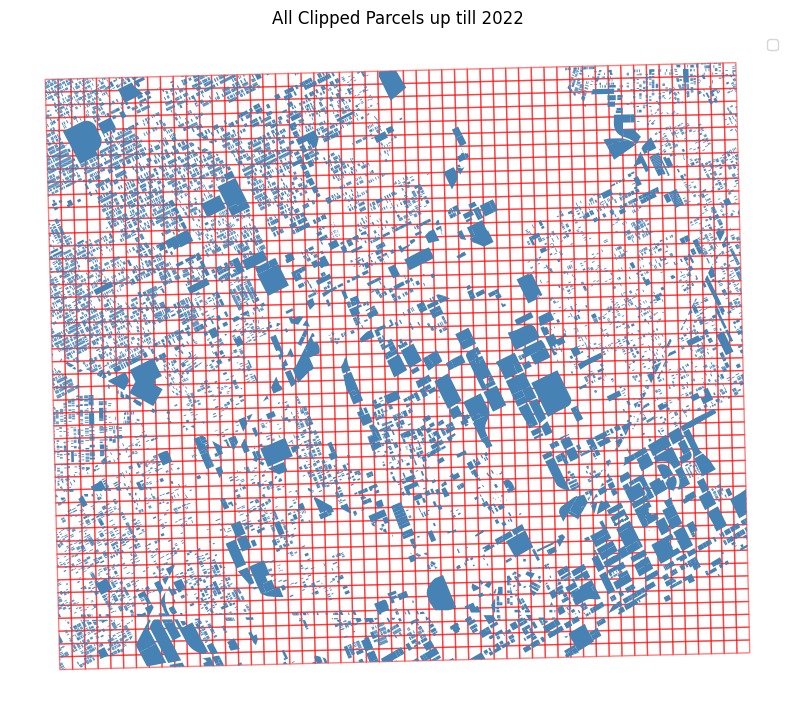

In [54]:
fig, ax = plt.subplots(figsize=(10, 10))

grid_4326 = grid.to_crs("EPSG:4326") # for plotting in lat/lon

merged_clipped_4326 = merged_clipped.to_crs("EPSG:4326") # for plotting in lat/lon

# Plot the gpkg boundary
grid_4326.plot(ax=ax, color="none", edgecolor="red", alpha=0.5, linewidth=1, label="gpkg boundary")

# Plot clipped merged parcels
merged_clipped_4326.plot(ax=ax, color="steelblue", label="clipped parcels")


plt.legend()
plt.title("All Clipped Parcels up till 2022")
plt.axis("off")
plt.show()

In [ ]:
print(merged_clipped.head())

         object_id     parcel_id               address zip_code                          taxpayer_1                       taxpayer_2                taxpayer_address     taxpayer_city taxpayer_state taxpayer_zip_code  ...  price commercial  emergency_ latitude longitude dlba_sale_  amt_final_ sale_progr  street_pre  address_id
148722  24354055.0  08008283-303  1401 ROSA PARKS BLVD    48216            1401 ROSA PARKS BLVD LLC                                                1092 WOODWARD AVE           DETROIT             MI             48226  ...    NaN        NaN         NaN      NaN       NaN        NaN         NaN        NaN         NaN         NaN
148723  24354064.0     08008706.           1448 WABASH    48216          ELIZABETH STREET LOFTS INC                                                     1600 CLAY ST           DETROIT             MI             48211  ...    NaN        NaN         NaN      NaN       NaN        NaN         NaN        NaN         NaN         NaN
148721  24354054

(2484, 9)
index                  0
vacant_2018          377
vacant_2022          377
vacant_count_2018      0
vacant_count_2022      0
became_vacant          0
redeveloped            0
still_vacant           0
never_vacant           0
dtype: int64


c:\Users\Angel\Documents\GitHub\musa-650-spring2026\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Angel\Documents\GitHub\musa-650-spring2026\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Angel\Documents\GitHub\musa-650-spring2026\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Angel\Documents\GitHub\musa-650-spring2026\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (9).

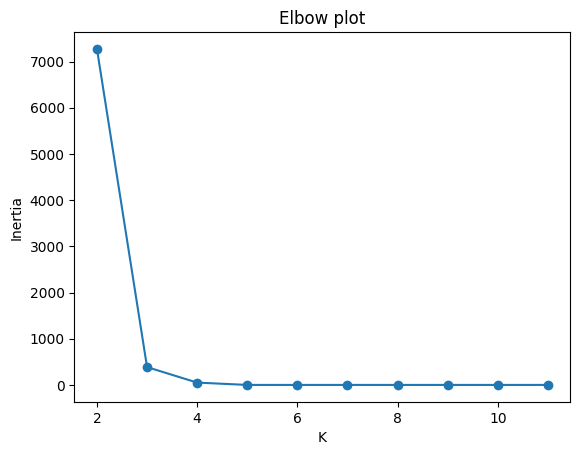

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Aggregate parcel flags to grid cell level
parcels_to_grid = gpd.sjoin(
    grid.reset_index(),
    merged_clipped[["geometry", "likely_vacant_2018", "likely_vacant_2022"]].to_crs("EPSG:26917"),
    how="left",
    predicate="intersects"
)

grid_agg = parcels_to_grid.groupby("index").agg(
    vacant_2018       = ("likely_vacant_2018", "max"),
    vacant_2022       = ("likely_vacant_2022", "max"),
    vacant_count_2018 = ("likely_vacant_2018", "sum"),
    vacant_count_2022 = ("likely_vacant_2022", "sum")
).reset_index()

# Add change features
grid_agg["became_vacant"] = (grid_agg["rebuilt_"] == 1) & (grid_agg["vacant_2018"] == 0)
grid_agg["redeveloped"]   = (grid_agg["vacant_2022"] == 0) & (grid_agg["vacant_2018"] == 1)
grid_agg["still_vacant"]  = (grid_agg["vacant_2022"] == 1) & (grid_agg["vacant_2018"] == 1)
grid_agg["never_vacant"]  = (grid_agg["vacant_2022"] == 0) & (grid_agg["vacant_2018"] == 0)

print(grid_agg.shape)
print(grid_agg.isnull().sum())

# Fill NAs
grid_agg = grid_agg.fillna(0)

# Feature matrix
feature_cols = [
    "vacant_2018",
    "vacant_2022",
    "vacant_count_2018",
    "vacant_count_2022",
    "became_vacant",
    "redeveloped",
    "still_vacant"
]

X = grid_agg[feature_cols].values
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow plot
inertias = []
for k in range(2, 12):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2, 12), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow plot")
plt.show()

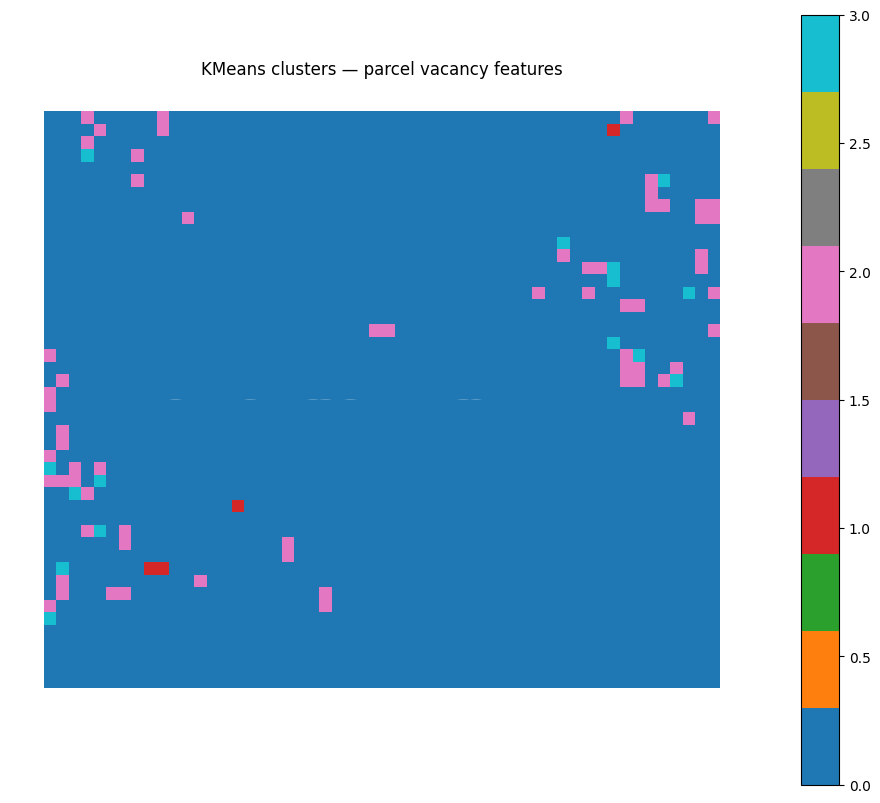

In [63]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
grid_agg["cluster"] = kmeans.fit_predict(X_scaled)

# Join geometry back
grid_clustered = gpd.GeoDataFrame(
    grid.reset_index().merge(
        grid_agg[["index", "cluster"] + feature_cols], 
        on="index", 
        how="left"
    ),
    crs=grid.crs
)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

grid_clustered.plot(
    column  = "cluster",
    cmap    = "tab10",
    legend  = True,
    ax      = ax
)


plt.title("KMeans clusters — parcel vacancy features")
plt.axis("off")
plt.show()